# REDES NEURONALES

---



En esta actividad vamos a utilizar una red neuronal para clasificar imágenes de dígitos del 0 al 9 escritos a mano. Para ello, utilizaremos Keras con TensorFlow.

El dataset a utilizar es MNIST, una base de datos constituida por (como no) imágenes de dígitos escritos a mano. Este dataset es ampliamente utilizado en docencia como punto de entrada al entrenamiento de redes neuronales y otros, pero también es muy utilizado en trabajos reales de investigación para el entrenamiento de imágenes. Puedes consultar más información sobre el dataset en [este enlace](https://es.wikipedia.org/wiki/Base_de_datos_MNIST).

El código utilizado para contestar tiene que quedar claramente reflejado en el Notebook. Puedes crear nuevas celdas si así lo deseas para estructurar tu código y sus salidas. A la hora de entregar el notebook, **asegúrate de que los resultados de ejecutar tu código han quedado guardados y que son perfectamente visibles en la versión PDF que debes entregar adjunta**. Por ejemplo, a la hora de entrenar una red neuronal tiene que verse claramente un log de los resultados de cada epoch.

In [123]:
from keras.datasets.mnist import load_data
import tensorflow as tf
import matplotlib.pyplot as plt

Tenemos la suerte de que el dataset MNIST, el que vamos a utilizar en esta actividad, está guardado en Keras, por lo que podemos utilizarlo sin necesidad de buscar el dataset de forma externa.

In [124]:
mnist = tf.keras.datasets.fashion_mnist

Llamar a **load_data** en este dataset nos dará dos conjuntos de dos listas, estos serán los valores de entrenamiento y prueba para los gráficos que contienen los dígitos y sus etiquetas.

Nota: Aunque en esta actividad lo veis de esta forma, también lo vais a poder encontrar como 4 variables de esta forma: training_images, training_labels, test_images, test_labels = mnist.load_data()

In [125]:
(training_images, training_labels), (test_images, test_labels) = load_data()

Antes de continuar vamos a dar un vistazo a nuestro dataset, para ello vamos a ver una imagen de entrenamiento y su etiqueta o clase.

5
[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   3  18  18  18 126 136 175  26 166 255 247 127   0   0   0   0]
 [  0   0   0   0   0   0   0   0  30  36  94 154 170 253 253 253 253 253 225 172 253 242 195  64   0   0   0   0]
 [  0   0   0   0   0   0   0  49 238 253 253 253 253 253 253 253 253 251  93  82  82  56  39   0   0   0   0   0]
 [  0   0   0   0   0   0   0  18 219 253 253 253 253 253 198 182 247 241   0 

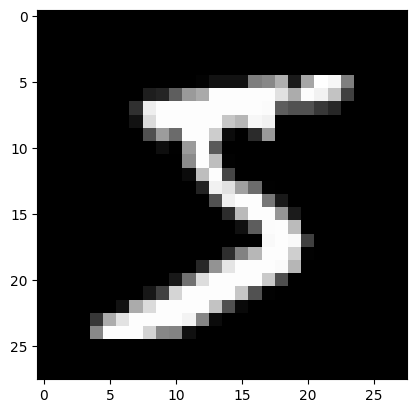

In [126]:
import numpy as np
np.set_printoptions(linewidth=200)
plt.imshow(training_images[0], cmap="gray") # recordad que siempre es preferible trabajar en blanco y negro
#
print(training_labels[0])
print(training_images[0])

## <p style="color:red">1. Información sobre el dataset</p>

Una vez tenemos los datos cargados en memoria, vamos a obtener información sobre los mismos.

**Pregunta <p style="color:yellow">1.1 *(0.25 puntos)*** ¿Cuántas imágenes hay de *training* y de *test*? ¿Qué tamaño tienen las imágenes?</p>

In [127]:
print(f"Hay {len(training_images)} imágenes de entrenamiento y {len(test_images)} imágenes de test")
print(f"El tamaño de cada imagen es {training_images[0].shape} pixeles")

Hay 60000 imágenes de entrenamiento y 10000 imágenes de test
El tamaño de cada imagen es (28, 28) pixeles


**Pregunta <p style="color:yellow">1.2 *(0.25 puntos)*** Realizar una exploración de las variables que contienen los datos. Describir en qué consiste un example del dataset (qué información se guarda en cada imagen) y describir qué contiene la información en y.</p>

In [128]:
print("Representación numérica de la imagen:")
print(training_images[0])

print("Etiqueta de la imagen:")
print(training_labels[0])

Representación numérica de la imagen:
[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   3  18  18  18 126 136 175  26 166 255 247 127   0   0   0   0]
 [  0   0   0   0   0   0   0   0  30  36  94 154 170 253 253 253 253 253 225 172 253 242 195  64   0   0   0   0]
 [  0   0   0   0   0   0   0  49 238 253 253 253 253 253 253 253 253 251  93  82  82  56  39   0   0   0   0   0]
 [  0   0   0   0   0   0   0  18 219 253 

<p>Las variables <b>training_images</b> y <b>test_images</b> contienen imágenes de dígitos escritos a mano representadas como matrices de tamaño 28x28 píxeles. Cada píxel tiene un valor entero entre 0 y 255, donde 0 representa el fondo (negro) y 255 la máxima intensidad (blanco), con valores intermedios.</p>
<p>Las variables <b>training_labels</b> y <b>test_labels</b> contienen la etiqueta asociada a cada imagen, es decir, un valor entero entre 0 y 9 que indica qué dígito representa la imagen correspondiente.</p>
<p>De esta forma, cada input está asociado a una etiqueta formando pares <b>(x, y)</b> para entrenar un modelo de clasificación.</p>


## <p style="color:red">2. Normalización y preprocesado de los datos</p>

**<p style="color:yellow">Pregunta 2.1 (0.25 puntos)** Habreis notado que todos los valores numericos están entre 0 y 255. Si estamos entrenando una red neuronal, una buena practica es transformar todos los valores entre 0 y 1, un proceso llamado "normalización" y afortunadamente en Python es fácil normalizar una lista. ¿Cómo lo podemos hacer?</p>

In [129]:
# Normalizamos imagenes
training_images = training_images / 255.0
test_images = test_images / 255.0
# No se normalizan labels ya que son categoricas (0-9)

# Comprobamos
print(f"Valores mínimo y máximo de training_images: {training_images.min()} - {training_images.max()}")
print("Primer ejemplo (matriz de píxeles normalizados):\n", training_images[0])

Valores mínimo y máximo de training_images: 0.0 - 1.0
Primer ejemplo (matriz de píxeles normalizados):
 [[0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.         0.         0.         0.         0.  

**<p style="color:yellow">Pregunta 2.2 (0.25 puntos)** Utiliza la función ***reshape*** de Numpy para convertir las imágenes en vectores de características de un tamaño de (N, 784). Explica con tus palabras por qué es necesario hacer esto.</p>



In [130]:
training_images = training_images.reshape(training_images.shape[0], 784)
test_images = test_images.reshape(test_images.shape[0], 784)

**Respuesta a la pregunta 2.2**:
<p>Es necesario aplicar la función <code>reshape</code> para convertir el vector 2D de 28x28 en un vector de 1D con 748 elementos (28x28=748) ya que los perceptrones multicapa requieren vectores de valores unidimensionales.</p>
<p>Por lo tanto, despues de aplicar la función tendriamos un vector de tamaño (N, 748), donde N es el número de imagenes del dataset.</p>


**<p style="color:yellow">Pregunta 2.3 (0.25 puntos)** Para facilitar el desarrollo de la actividad, vamos a expresar las etiquetas así:</p>

In [131]:
training_labels = tf.keras.utils.to_categorical(training_labels)
test_labels = tf.keras.utils.to_categorical(test_labels)

<p style="color:yellow">Muestra cómo son ahora los datos, como resultado de este cambio y también de los realizados en las dos preguntas anteriores. Debate cómo se beneficiará la red neuronal de todos estos cambios.</p>

In [132]:
print("Primeras 9 etiquetas de entrenamiento con one-hot encoding:")

print("0\t1\t2\t3\t4\t5\t6\t7\t8\t9")
print(training_labels[:9])

Primeras 9 etiquetas de entrenamiento con one-hot encoding:
0	1	2	3	4	5	6	7	8	9
[[0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]]


Respuesta a la pregunta 2.3:
<p>Con la función <code>to_categorical</code> aplicamos one-hot encoding que consiste en convertir la variable categoria en una variable unidimensional donde todas las posiciones son 0 excepto la que corresponde a la clase de la etiqueta.</p>

## <p style="color:red">3. Creación del Modelo</p>

Ahora vamos a definir el modelo, pero antes vamos a repasar algunos comandos y conceptos muy útiles:
* **Sequential**: Eso define una SECUENCIA de capas en la red neuronal
* **Dense**: Añade una capa de neuronas
* **Flatten**: ¿Recuerdas cómo eran las imágenes cuando las imprimiste para poder verlas? Un cuadrado, Flatten toma ese cuadrado y lo convierte en un vector de una dimensión.

Cada capa de neuronas necesita una función de activación. Normalmente se usa la función relu en las capas intermedias y softmax en la ultima capa (en problemas de clasificación de más de dos items)
* **Relu** significa que "Si X>0 devuelve X, si no, devuelve 0", así que lo que hace es pasar sólo valores 0 o mayores a la siguiente capa de la red.
* **Softmax** toma un conjunto de valores, y escoge el más grande.

 **Pregunta 3.1 (0.5 puntos)**. Utilizando Keras, y preparando los datos de X e Y como fuera necesario, define y entrena una red neuronal que sea capaz de clasificar imágenes de MNIST con las siguientes características:

* Una capa de entrada del tamaño adecuado.
* Una capa oculta de 512 neuronas.
* Una capa final con 10 salidas.

In [133]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Flatten, Dense

In [134]:
model = Sequential([
    Dense(512, activation='relu', input_shape=(784,)),
    Dense(10, activation='softmax'),
])

**Pregunta 3.2 (0.25 puntos)**: ¿crees conveniente utilizar una capa flatten en este caso? Motiva tu respuesta.



In [135]:
# Volvemos a cargar los datos del dataset sin transformar y normalizar
# (training_images, training_labels), (test_images, test_labels) = load_data()

# model = Sequential([
#     Flatten(input_shape=(28, 28)),
#     Dense(512, activation='relu'),
#     Dense(10, activation='softmax'),
# ])


**Respuesta a la pregunta 3.2**:
<p>Según como se ha desarrollado el ejercicio, no sería necesario definir una capa <code>Flatten</code> para aplanar el vector de imagen, ya que antes aplicamos <code>reshape</code> para conseguir el mismo objetivo. Transformar el vector 2D a un vector unidimensional con 784 elementos.</p>
<p>Una de las diferencias entre estas funciones es que con <code>reshape</code> transformados los datos en el preprocesado, mientras que con <code>Flatten</code> lo haríamos durante durante el entrenamiento.</p>

**Pregunta 3.3 (0.25 puntos)**: Utiliza la función summary() para mostrar la estructura de tu modelo.

In [136]:
# Mostramos la arquitectura resumida
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 407,050 (1.55 MB)

 Trainable params: 407,050 (1.55 MB)

 Non-trainable params: 0 (0.00 B)

## <p style="color:red">4: Compilación y entrenamiento</p>

**Pregunta 4.1 (0.5 puntos)**: Compila tu modelo. Utiliza ***categorical_crossentropy*** como función de pérdida, ***Adam*** como optimizador, y monitoriza la ***tasa de acierto*** durante el entrenamiento. Explica qué hace cada cosa en la compilación.

In [137]:
# Compilamos el modelo
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

**Respuesta a la pregunta 4.1**:

Configuramos el modelo con los valores del optimizador, función de perdida y metrica para evaluar el rendimiento del modelo.

Para el caso de la función de perdida, podemos utiliar ***categorical_crossentropy*** al convertir nuestra variable categorica a one-hot-encoding. De no haberlo hecho tendriamos que utilizar otra función de perdida como ***spare_categorical_crossentropy***.


**Pregunta 4.2 (0.5 puntos)**: Utiliza la función ***fit()*** para entrenar tu modelo. Para ayudarte en tu primer entrenamiento, utiliza estos valores:
*   epochs = 5
*   batch_size = 32
*   validation_split = 0.25



In [138]:
# Entrenamos
history = model.fit(
    training_images, training_labels,               # Datos de entrenamiento: imágenes y etiquetas (one-hot)
    validation_data=(test_images, test_labels),  # Datos de validación: se usan para evaluar la red después de cada época
    epochs=5,                      # Número de pasadas completas por todo el dataset
    batch_size=32,                  # Número de muestras que la red procesa antes de actualizar los pesos
    verbose=1                        # Muestra información del entrenamiento: pérdidas y precisión por época
)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8:03 258ms/step - accuracy: 0.1250 - loss: 2.37 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.5509 - loss: 1.5135   ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.6122 - loss: 1.32 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.6532 - loss: 1.19 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7013 - loss: 1.02 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7298 - loss: 0.93 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7499 - loss: 0.86 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7656 - loss: 0.81 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7791 - loss: 0.76 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7897 - loss: 0.72 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7984 - loss: 0.69 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8043 - loss: 0.67 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8108 - loss: 0.65 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8167 - loss: 0.63 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8221 - loss: 0.

***Respuesta a la pregunta 4.2***

Cambiamos el valor de ***verbose*** a 1 para tener el resultado de las metricas durante el entrenamiento.

Durante cada época, el modelo muestra los valores intermedios de ***accuracy*** y ***loss*** que se generan por cada ***batch_size***. Los valores relevantes son los que aparecen al final de cada epoca ya que representa el rendimiento global de todo el modelo. En este sentido, los valores de ***val_accuracy*** y ***val_loss*** muestran el rendimiento del modelo con los datos de validación que permite evaluar el comportamiento del modelo con datos no vistos durante el entrenamiento.

El modelo muestra mejora progresiva en la metrica de ***accuracy*** y una reducción de ***loss*** durante las primeras épocas. Sin embargo, en las últimas épocas el valor de ***accuracy*** y ***loss*** casi no cambia, así como los valores de ***val_accuracy*** y ***val_loss*** lo que indica un posible sobreajuste (overfitting)

# <p style="color:red">5: Impacto al variar el número de neuronas en las capas ocultas</p>

En este ejercicio vamos a experimentar con nuestra red neuronal cambiando el numero de neuronas por 512 y por otros valores. Para ello, utiliza la red neuronal de la pregunta 3, y su capa oculta cambia el número de neuronas:

* **216 neuronas en la capa oculta
* **1024 neuronas en la capa oculta

y entrena la red en ambos casos.



In [140]:
### Tu código para 216 neuronas aquí ###
model = Sequential([
    Dense(216, activation='relu', input_shape=(784,)),
    Dense(10, activation='softmax'),
])

# Compilamos el modelo
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

# Entrenamos
history = model.fit(
    training_images, training_labels,
    validation_data=(test_images, test_labels),
    epochs=5,
    batch_size=32,
    verbose=1
)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10:27 335ms/step - accuracy: 0.1562 - loss: 2.373 ━━━━━━━━━━━━━━━━━━━━ 1s 967us/step - accuracy: 0.5113 - loss: 1.5834  ━━━━━━━━━━━━━━━━━━━━ 1s 970us/step - accuracy: 0.6258 - loss: 1.24 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.6776 - loss: 1.0840 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7114 - loss: 0.97 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7348 - loss: 0.90 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7529 - loss: 0.84 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7658 - loss: 0.79 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7766 - loss: 0.76 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7864 - loss: 0.72 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7950 - loss: 0.70 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7976 - loss: 0.69 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8008 - loss: 0.68 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8076 - loss: 0.65 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8135 - l

In [141]:
### Tu código para 1024 neuronas aquí ###
model = Sequential([
    Dense(1024, activation='relu', input_shape=(784,)),
    Dense(10, activation='softmax'),
])

# Compilamos el modelo
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

# Entrenamos
history = model.fit(
    training_images, training_labels,
    validation_data=(test_images, test_labels),
    epochs=5,
    batch_size=32,
    verbose=1
)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8:19 266ms/step - accuracy: 0.0312 - loss: 2.35 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.4489 - loss: 1.6142   ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.5776 - loss: 1.27 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.6473 - loss: 1.07 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.6863 - loss: 0.96 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7109 - loss: 0.89 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7297 - loss: 0.83 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7448 - loss: 0.79 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7573 - loss: 0.75 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7679 - loss: 0.72 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7761 - loss: 0.69 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7831 - loss: 0.67 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7905 - loss: 0.65 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7973 - loss: 0.63 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8034 - loss: 0.

**Pregunta 5.1 (0.5 puntos)**: ¿Cual es el impacto que tiene la red neuronal?

Los resultados de ambas simulaciones son bastante similares en cuanto al ***val_accuracy***, lo que indica que el aumento de neuronas no aporta una mejora significativa en este caso.

Hay una ligera diferencia entre el valor de ***accuracy*** de entrenamiento y el ***val_accuracy*** lo que sugiere la presencia de un ligero sobreajuste. Los modelos con 216 y 1024 neuronas presentan un sobreajuste similar entre si.

Respuesta a la pregunta 5.1:

# <p style="color:red">6: Número de neuronas de la capa de salida</p>
Considerad la capa final, la de salida de la red neuronal de la pregunta 3.

**Pregunta 6.1 (0.25 puntos)**: ¿Por qué son 10 las neuronas de la última capa?

**Pregunta 6.2 (0.25 puntos)**: ¿Qué pasaría si tuvieras una cantidad diferente a 10?

Por ejemplo, intenta entrenar la red con 5, para ello utiliza la red neuronal de la pregunta 1 y cambia a 5 el número de neuronas en la última capa.

In [142]:
### Tu código de la red neuronal con 5 neuronas en la capa de salida de la pregunta 7 aquí ###
model = Sequential([
    Dense(216, activation='relu', input_shape=(784,)),
    Dense(5, activation='softmax'),
])

# Compilamos el modelo
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

# Entrenamos
history = model.fit(
    training_images, training_labels,
    validation_data=(test_images, test_labels),
    epochs=5,
    batch_size=32,
    verbose=1
)

Epoch 1/5


ValueError: Arguments `target` and `output` must have the same shape. Received: target.shape=(32, 10), output.shape=(32, 5)

***Tu respuestas a la pregunta 6.1 aquí:***

El modelo tiene una última capa con 10 neuronas porque consiste en clasificar 10 clases de digitos entre el 0 al 9. Cada neurona de la capa de salida representa la posibilidad de que la predicción de la imagen pertenezca a esa clase.

Como utilizamos one-hot encoding cada etiqueta está representada en un vector de 10 elementos.


***Tu respuestas a la pregunta 6.2 aquí:***

Si tuvieramos menos de 10 neuronas el modelo perderia la capacidad de representar todas las clases del problema.

Por ejemplo si la última capa tiene 5 neuronas, el modelo podria predecir solo 5 clases distintas, lo que provocaria errores.

Despues de intentar ejecutar la celda con la configuración de 5 neuronas tenemos el siguiente mensaje de error:

***ValueError: Arguments `target` and `output` must have the same shape. Received: target.shape=(32, 10), output.shape=(32, 5)***

Se puede observar que el mensaje indica que las dimensiones de la clase objetivo es de 10, mientras que la salida tiene una dimensión de 5. Este es el tipo de errores que comentaba anteriormente.

# <p style="color:red">7: Aumento de epoch y su efecto en la red neuronal</p>
En este ejercicio vamos a ver el impacto de aumentar los epoch en el entrenamiento. Usando la red neuronal de la pregunta 3:

**Pregunta 7.1 (0.25 puntos)**
* Intentad 15 epoch para su entrenamiento, probablemente obtendras un modelo con una pérdida mucho mejor que el que tiene 5.

**Pregunta 7.2 (0.25 puntos)**
* Intenta ahora con 30 epoch para su entrenamiento.

**Pregunta 7.3 (0.25 puntos)**
* ¿Qué está pasando en la pregunta anterior? Explica tu respuesta y da el nombre de este efecto si lo conoces.

In [143]:
### Tu código para 15 epoch aquí ###
model = Sequential([
    Dense(512, activation='relu', input_shape=(784,)),
    Dense(10, activation='softmax'),
])

# Compilamos el modelo
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

# Entrenamos
history = model.fit(
    training_images, training_labels,
    validation_data=(test_images, test_labels),
    epochs=15,
    batch_size=32,
    verbose=1
)

Epoch 1/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11:18 362ms/step - accuracy: 0.0312 - loss: 2.351 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.4972 - loss: 1.5303    ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.6187 - loss: 1.20 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.6773 - loss: 1.03 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.7097 - loss: 0.93 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7327 - loss: 0.86 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7502 - loss: 0.81 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7648 - loss: 0.76 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7767 - loss: 0.72 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7867 - loss: 0.69 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7954 - loss: 0.67 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8029 - loss: 0.64 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8097 - loss: 0.62 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8157 - loss: 0.60 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8211 - loss

In [144]:
### Tu código para 30 epoch aquí ###
model = Sequential([
    Dense(512, activation='relu', input_shape=(784,)),
    Dense(10, activation='softmax'),
])

# Compilamos el modelo
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

# Entrenamos
history = model.fit(
    training_images, training_labels,
    validation_data=(test_images, test_labels),
    epochs=30,
    batch_size=32,
    verbose=1
)

Epoch 1/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8:03 258ms/step - accuracy: 0.1875 - loss: 2.30 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.5537 - loss: 1.5169   ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.6529 - loss: 1.20 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.6999 - loss: 1.04 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7281 - loss: 0.94 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7489 - loss: 0.87 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7649 - loss: 0.82 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7775 - loss: 0.77 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7871 - loss: 0.74 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7960 - loss: 0.71 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8031 - loss: 0.68 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8097 - loss: 0.66 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8155 - loss: 0.64 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8209 - loss: 0.62 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8257 - loss: 0

Tu respuesta a la pregunta 7.3 aquí:

Lo que ocurre en la pregunta anterior es que el modelo alcanza un ***accurace*** muy alta y un valor de ***loss*** casi nula, lo que indica que el modelo ha aprendido los datos de entrenamiento muy bien.

Por otro lado, los valores de validación no mejoran en la misma proporción. Nos indica que el modelo no está generalizando correctamente. Esto se conoce como overfitting, que ocurre cuando el modelo tiene exceso de entrenamiento (30 epochs) y el modelo memoriza los datos de entrenamiento en lugar de generalizar a datos no vistos.


# <p style="color:red">8: Early stop</p>
En el ejercicio anterior, cuando entrenabas con epoch extras, tenías un problema en el que tu pérdida podía cambiar. Puede que te haya llevado un poco de tiempo esperar a que el entrenamiento lo hiciera,  y puede que hayas pensado "¿no estaría bien si pudiera parar el entrenamiento cuando alcance un valor deseado?", es decir, una precisión del 85% podría ser suficiente para ti, y si alcanzas eso después de 3 epoch, ¿por qué sentarte a esperar a que termine muchas más épocas? Como cualquier otro programa existen formas de parar la ejecución

A partir del código de ejemplo, hacer una nueva función que tenga en cuenta la perdida (loss) y que pueda parar el código para evitar que ocurra el efeto secundario que vimos en el ejercicio 5.

In [ ]:
### Ejemplo de código

class myCallback(tf.keras.callbacks.Callback):
      def on_epoch_end(self, epoch, logs={}):
        if(logs.get('accuracy')> 0.85):
              print("\nAlcanzado el 85% de precisión, se cancela el entrenamiento!!")
              self.model.stop_training = True

**Pregunta 8.1. *(0.75 puntos)***: Consulta la documentación de Keras y aprende cómo podemos utilizar Early stop en nuestro modelos.

In [146]:
# ajustamos a acurracy de validación
class myCallback(tf.keras.callbacks.Callback):
      def on_epoch_end(self, epoch, logs={}):
        if(logs.get('val_accuracy')> 0.85):
              print("\nAlcanzado el 85% de precisión, se cancela el entrenamiento!!")
              self.model.stop_training = True

callback = myCallback()

# Entrenamos
history = model.fit(
    training_images, training_labels,
    validation_data=(test_images, test_labels),
    epochs=30,
    batch_size=32,
    verbose=1,
    callbacks=[callback]
)


Epoch 1/30
1859/1875 ━━━━━━━━━━━━━━━━━━━━ 1:23 44ms/step - accuracy: 1.0000 - loss: 7.6732e-0 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 1.0000 - loss: 2.2279e-04  ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 1.0000 - loss: 6.0768e- ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9997 - loss: 0.0014   ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9996 - loss: 0.00 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9994 - loss: 0.00 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9994 - loss: 0.00 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9994 - loss: 0.00 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9993 - loss: 0.00 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9993 - loss: 0.00 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9993 - loss: 0.00 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9993 - loss: 0.00 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9992 - loss: 0.00 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9992 - loss: 0.00 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0

Se entrena el modelo y se define un early stop para parar el entrenamiento si se supera el 85% del ***val_accuracy**, donde medimos el rendimiento del modelo con los datos de validación.

## <p style="color:red">9. Unidades de activación</p>

En este ejercicio, vamos a evaluar la importancia de utilizar las unidades de activación adecuadas. Como hemos visto en clase, funciones de activación como sigmoid han dejado de utilizarse en favor de otras unidades como ReLU.

**Pregunta 9.1 *(0.75 puntos)***: Utilizando la red realizada en el ejercicio 3, escribir un breve análisis comparando la utilización de unidades sigmoid y ReLU (por ejemplo, se pueden comentar aspectos como velocidad de convergencia, métricas obtenidas...). Explicar por qué pueden darse estas diferencias. Opcionalmente, comparar con otras activaciones disponibles en Keras.

*Pista: Usando redes más grandes se hace más sencillo apreciar las diferencias. Es mejor utilizar al menos 3 o 4 capas densas.*

In [ ]:
## Tu código y comentarios de texto aquí
## Puedes incluir tantas celdas como quieras
## No olvides utilizar celdas de Markdown para texto

# RELU
model_relu = Sequential([
    Dense(512, activation='relu', input_shape=(784,)),
    Dense(512, activation='relu'),
    Dense(512, activation='relu'),
    Dense(10, activation='softmax'),
])

model_relu.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

history_relu = model_relu.fit(
    training_images, training_labels,
    validation_data=(test_images, test_labels),
    epochs=5,
    batch_size=32,
    verbose=1
)


Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13:18 426ms/step - accuracy: 0.0312 - loss: 2.313 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.4597 - loss: 1.7210    ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.5705 - loss: 1.39 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.6262 - loss: 1.22 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.6594 - loss: 1.11 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.6867 - loss: 1.02 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.7032 - loss: 0.97 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7154 - loss: 0.93 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7261 - loss: 0.90 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7356 - loss: 0.86 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7439 - loss: 0.84 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7515 - loss: 0.81 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7583 - loss: 0.79 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7645 - loss: 0.77 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7702 - loss:

In [ ]:
# SIGMOID
model_sigmoid = Sequential([
    Dense(512, activation='sigmoid', input_shape=(784,)),
    Dense(512, activation='sigmoid'),
    Dense(512, activation='sigmoid'),
    Dense(10, activation='softmax'),
])

model_sigmoid.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

history_sigmoid = model_sigmoid.fit(
    training_images, training_labels,
    validation_data=(test_images, test_labels),
    epochs=5,
    batch_size=32,
    verbose=1
)

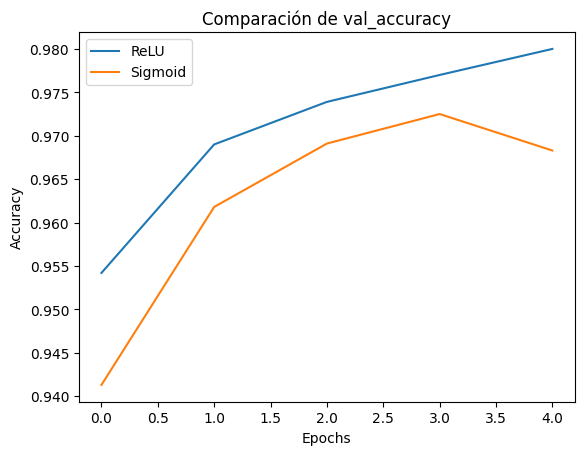

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history_relu.history['val_accuracy'], label='ReLU')
plt.plot(history_sigmoid.history['val_accuracy'], label='Sigmoid')
plt.title('Comparación de val_accuracy ReLU vs Sigmoid')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

***Respuesta:***

Se ha comparado el comportamiento de los modelos cambiando unicamente la función de activación de ReLU vs Sigmoid.

La grafica muestra que el modelo con ReLU converge más rápido y alcanza una accuracy mayor en validación en comparación con Sigmoid.

La función de activación Sigmoid tiene un problema cuando los gradientes son cercanos a cero, ya que el modelo no aprende o lo hace muy lento ya que lo pesos cambian muy poco durante el entrenamiento. A este problema se le conoce como ***vanishing gradient*** que se observa en mayor medida en redes profundas.

En general el resultado de ***val_accuracy*** con la función de activación de ReLU es superior al calculado con Sigmoid.

In [166]:
# LEAKY RELU
model_leaky_relu = Sequential([
    Dense(512, activation='leaky_relu', input_shape=(784,)),
    Dense(512, activation='leaky_relu'),
    Dense(512, activation='leaky_relu'),
    Dense(10, activation='softmax'),
])

model_leaky_relu.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

history_leaky_relu = model_leaky_relu.fit(
    training_images, training_labels,
    validation_data=(test_images, test_labels),
    epochs=5,
    batch_size=32,
    verbose=1
)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 22:35 723ms/step - accuracy: 0.2188 - loss: 2.253 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.5324 - loss: 1.5269    ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.6221 - loss: 1.23 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.6694 - loss: 1.07 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.7013 - loss: 0.96 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.7248 - loss: 0.88 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.7385 - loss: 0.84 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7481 - loss: 0.81 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7565 - loss: 0.78 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7640 - loss: 0.76 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7706 - loss: 0.73 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7766 - loss: 0.71 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7820 - loss: 0.70 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7869 - loss: 0.68 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7913 - loss:

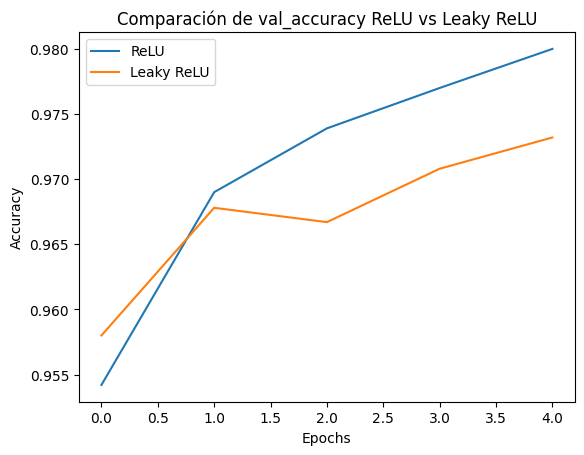

In [167]:
import matplotlib.pyplot as plt

plt.plot(history_relu.history['val_accuracy'], label='ReLU')
plt.plot(history_leaky_relu.history['val_accuracy'], label='Leaky ReLU')
plt.title('Comparación de val_accuracy ReLU vs Leaky ReLU')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

***Respuesta:***

En la grafica anterior se observa que el modelo con Leaky ReLU tiene una accuracy mayor en las primeras épocas, indica que tiene un aprendizaje más rápido ya que evita el problema de neuronas muertas que tiene ReLU. El problema de neuronas muertas de ReLU se da por los gradientes con valor 0 lo que provoca que las neuronas no aprendan.

Sin embargo, según avanzan las épocas el modelo con ReLU alcanza una mayor accuracy en validación, lo que indica que este modelo tiene una mejor capacidad de generalización para este dataset.

En general, estas comparaciones permiten observar que según la función de activación se puede alcanzar una mayor convergencia según el problema.


## <p style="color:red">10. Inicialización de parámetros</p>

En este ejercicio, vamos a evaluar la importancia de una correcta inicialización de parámetros en una red neuronal.

**Pregunta 10.1 *(0.75 puntos)***: Partiendo de una red similar a la del ejercicio anterior (usando ya ReLUs), comentar las diferencias que se aprecian en el entrenamiento al utilizar distintas estrategias de inicialización de parámetros. Para ello, inicializar todas las capas con las siguientes estrategias, disponibles en Keras, y analizar sus diferencias:

* Inicialización con ceros.
* Inicialización con una variable aleatoria normal.
* Inicialización con los valores por defecto de Keras para una capa Dense (estrategia *glorot uniform*)

In [169]:
from tensorflow.keras.initializers import Zeros

model_zeros = Sequential([
    Dense(512, activation='relu', input_shape=(784,),
          kernel_initializer=Zeros()),
    Dense(512, activation='relu',
          kernel_initializer=Zeros()),
    Dense(10, activation='softmax',
          kernel_initializer=Zeros())
])

model_zeros.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

history_zeros = model_zeros.fit(
    training_images, training_labels,
    validation_data=(test_images, test_labels),
    epochs=5,
    batch_size=32,
    verbose=1
)

/Users/josejp/Documents/2026/UNIR/Cuatrimestre_2/Redes Neuronales y Aprendizaje Profundo/.venv/lib/python3.13/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10:48 346ms/step - accuracy: 0.0938 - loss: 2.302 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.1067 - loss: 2.3026    ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.1071 - loss: 2.30 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.1063 - loss: 2.30 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.1059 - loss: 2.30 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.1061 - loss: 2.30 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.1064 - loss: 2.30 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.1066 - loss: 2.30 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.1069 - loss: 2.30 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.1073 - loss: 2.30 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.1077 - loss: 2.30 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.1082 - loss: 2.30 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.1088 - loss: 2.30 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.1092 - loss: 2.30 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.1094 - loss:

In [173]:
from tensorflow.keras.initializers import RandomNormal

model_random = Sequential([
    Dense(512, activation='relu', input_shape=(784,),
          kernel_initializer=RandomNormal(mean=0.0, stddev=0.1)),
    Dense(512, activation='relu',
          kernel_initializer=RandomNormal(mean=0.0, stddev=0.1)),
    Dense(10, activation='softmax',
          kernel_initializer=RandomNormal(mean=0.0, stddev=0.1))
])

model_random.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

history_random = model_random.fit(
    training_images, training_labels,
    validation_data=(test_images, test_labels),
    epochs=5,
    batch_size=32,
    verbose=1
)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13:22 428ms/step - accuracy: 0.0938 - loss: 4.234 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.4254 - loss: 2.0571    ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.5580 - loss: 1.54 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.6271 - loss: 1.29 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.6677 - loss: 1.14 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.6896 - loss: 1.06 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.7046 - loss: 1.01 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.7159 - loss: 0.97 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.7259 - loss: 0.93 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.7335 - loss: 0.91 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.7429 - loss: 0.87 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.7524 - loss: 0.84 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.7608 - loss: 0.81 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.7678 - loss: 0.79 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.7746 - loss:

In [175]:
from tensorflow.keras.initializers import GlorotUniform

model_glorot = Sequential([
    Dense(512, activation='relu', input_shape=(784,),
          kernel_initializer=GlorotUniform()),
    Dense(512, activation='relu',
          kernel_initializer=GlorotUniform()),
    Dense(10, activation='softmax',
          kernel_initializer=GlorotUniform())
])

model_glorot.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

history_glorot = model_glorot.fit(
    training_images, training_labels,
    validation_data=(test_images, test_labels),
    epochs=5,
    batch_size=32,
    verbose=1
)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12:30 400ms/step - accuracy: 0.1562 - loss: 2.317 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.4392 - loss: 1.6872    ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.5712 - loss: 1.32 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.6379 - loss: 1.12 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.6789 - loss: 1.00 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7001 - loss: 0.93 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.7160 - loss: 0.88 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.7291 - loss: 0.84 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.7413 - loss: 0.81 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.7516 - loss: 0.78 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.7602 - loss: 0.75 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.7679 - loss: 0.73 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.7748 - loss: 0.71 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.7811 - loss: 0.69 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.7869 - loss:

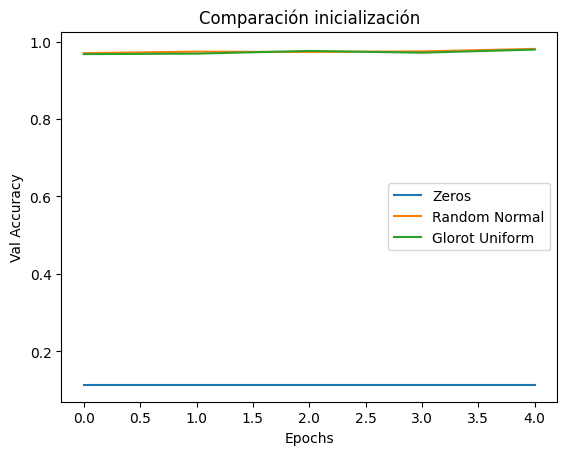

In [176]:
plt.plot(history_zeros.history['val_accuracy'], label='Zeros')
plt.plot(history_random.history['val_accuracy'], label='Random Normal')
plt.plot(history_glorot.history['val_accuracy'], label='Glorot Uniform')

plt.title('Comparación inicialización')
plt.xlabel('Epochs')
plt.ylabel('Val Accuracy')
plt.legend()
plt.show()

***Respuesta:***

En la gráfica podemos observar la comparación entre los 3 inicializadores ***Zeros***, ***Random Normal*** y ***Glorot Uniform***. La inicialización con ceros produce un modelo que no aprende ya que las neuronas tienen los mismos valores.

Por otro lado, la inicialización aleatoria y Glorot Uniform permiten qu el modelo aprenda correctamente. Alcanzan valores altos de ***val_accuracy***. Los resultados en ambos casos son muy similares. La diferencia principal entre estos inicializadores es que Glorot Uniform mantiene un rango de valores de gradiente durante el entrenamiento, mientras que Random Normal tiene una inicialización aleatoria y más sensible.

En general, la grafica muestra que la elección correcta de inicializaor es fundamental para el aprendizaje.


## <p style="color:red">11. Optimizadores</p>

**Problema 11.1 *(0.75 puntos)***: Partiendo de una red similar a la del ejercicio anterior (utilizando la mejor estrategia de inicialización observada), comparar y analizar las diferencias que se observan  al entrenar con varios de los optimizadores vistos en clase, incluyendo SGD como optimizador básico (se puede explorar el espacio de hiperparámetros de cada optimizador, aunque para optimizadores más avanzados del estilo de RMSprop es buena idea dejar los valores por defecto provistos por Keras).

In [177]:
from tensorflow.keras.optimizers import SGD, Adam, RMSprop, Adagrad

def create_model(optimizer):
    model = Sequential([
        Dense(512, activation='relu', input_shape=(784,),
              kernel_initializer='glorot_uniform'),
        Dense(512, activation='relu',
              kernel_initializer='glorot_uniform'),
        Dense(10, activation='softmax')
    ])

    model.compile(
        optimizer=optimizer,
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )
    
    return model


In [178]:
model_sgd = create_model(SGD(learning_rate=0.01))
history_sgd = model_sgd.fit(
    training_images, training_labels,
    validation_data=(test_images, test_labels),
    epochs=10,
    batch_size=32,
    verbose=1
)

/Users/josejp/Documents/2026/UNIR/Cuatrimestre_2/Redes Neuronales y Aprendizaje Profundo/.venv/lib/python3.13/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7:49 250ms/step - accuracy: 0.0938 - loss: 2.40 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.1870 - loss: 2.2774   ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.2877 - loss: 2.20 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.3552 - loss: 2.13 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.4000 - loss: 2.07 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.4363 - loss: 2.01 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.4662 - loss: 1.96 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.4913 - loss: 1.90 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.5131 - loss: 1.85 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.5322 - loss: 1.80 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.5485 - loss: 1.75 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.5610 - loss: 1.72 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.5743 - loss: 1.68 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.5869 - loss: 1.64 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.5986 - loss: 1

In [179]:
model_adam = create_model(Adam())
history_adam = model_adam.fit(
    training_images, training_labels,
    validation_data=(test_images, test_labels),
    epochs=10,
    batch_size=32,
    verbose=1
)

/Users/josejp/Documents/2026/UNIR/Cuatrimestre_2/Redes Neuronales y Aprendizaje Profundo/.venv/lib/python3.13/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10:52 348ms/step - accuracy: 0.0000e+00 - loss: 2.353 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.4410 - loss: 1.6884        ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.5751 - loss: 1.33 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.6383 - loss: 1.14 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.6772 - loss: 1.02 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.6987 - loss: 0.96 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7165 - loss: 0.90 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7315 - loss: 0.86 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7442 - loss: 0.82 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7550 - loss: 0.79 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.7635 - loss: 0.76 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.7701 - loss: 0.74 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.7762 - loss: 0.72 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.7820 - loss: 0.70 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.788

In [180]:
model_rms = create_model(RMSprop())
history_rms = model_rms.fit(
    training_images, training_labels,
    validation_data=(test_images, test_labels),
    epochs=10,
    batch_size=32,
    verbose=1
)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8:06 260ms/step - accuracy: 0.1562 - loss: 2.30 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.5002 - loss: 1.5187   ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.6067 - loss: 1.21 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.6608 - loss: 1.05 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.6949 - loss: 0.95 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7146 - loss: 0.89 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7312 - loss: 0.84 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7449 - loss: 0.79 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7566 - loss: 0.76 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7667 - loss: 0.73 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7755 - loss: 0.70 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7834 - loss: 0.68 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7904 - loss: 0.65 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7966 - loss: 0.64 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8024 - loss: 0

In [181]:
model_adagrad = create_model(Adagrad())
history_adagrad = model_adagrad.fit(
    training_images, training_labels,
    validation_data=(test_images, test_labels),
    epochs=10,
    batch_size=32,
    verbose=1
)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7:24 237ms/step - accuracy: 0.0938 - loss: 2.24 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.1066 - loss: 2.3010   ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.1269 - loss: 2.28 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.1520 - loss: 2.26 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.1743 - loss: 2.25 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.1943 - loss: 2.24 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.2137 - loss: 2.22 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.2323 - loss: 2.21 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.2490 - loss: 2.20 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.2653 - loss: 2.18 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.2808 - loss: 2.17 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.2956 - loss: 2.16 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.3096 - loss: 2.14 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.3236 - loss: 2.13 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.3367 - loss: 2

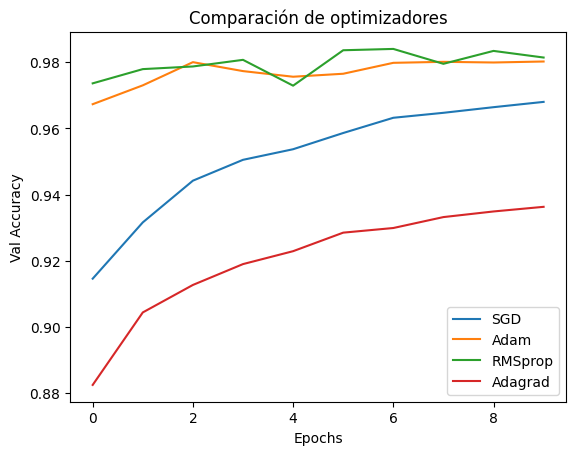

In [182]:
import matplotlib.pyplot as plt

plt.plot(history_sgd.history['val_accuracy'], label='SGD')
plt.plot(history_adam.history['val_accuracy'], label='Adam')
plt.plot(history_rms.history['val_accuracy'], label='RMSprop')
plt.plot(history_adagrad.history['val_accuracy'], label='Adagrad')

plt.title('Comparación de optimizadores')
plt.xlabel('Epochs')
plt.ylabel('Val Accuracy')
plt.legend()
plt.show()

***Respuesta:***

La grafica muestra que los optimizadores tienen diferentes comportamientos en la velocidad de convergencia y el rendimiento final del modelo.

El optimizador de peor comportamiento es Adagrad, tiene una convergencia lenta y un accuracy inferior. Se debe a que la reducción progresiva de learning rate, puede llegar a relentizar o detener el aprendizaje demasiado pronto.

El optimizador ***SGD*** muestra un comportamiento más progresivo y estable, pero sigue siendo más lenta en comparación al de los otros optimzadores.

Los optimzadores ***Adam*** y ***RMSprop*** muestran los mejores resultados, tienen convergencia más rápida y mayores valores de accuracy. Ambos utilizan una estrategia adaptativa de learning rate durante el entrenamiento, permitiendo un aprendizaje más eficiente.

En general, ***Adam*** y ***RMSprop*** son una opción más equilibrada y robusta para esta problematica. Sin embargo, ***RMSprop*** puede ofrecer resultados superiores, pero con mayor variabilidad. La selección de un optimizador es importante para mejorar la eficiencia del entrenamiento, así como el rendimiento final del modelo.



## <p style="color:red">12. Regularización y red final *(1.25 puntos)*</p>

**Problema 12.1 *(2 puntos)***: Entrenar una red final que sea capaz de obtener una accuracy en el validation superior al 95%. Para ello, combinar todo lo aprendido anteriormente y utilizar técnicas de regularización para evitar overfitting. Algunos de los elementos que pueden tenerse en cuenta son los siguientes.

* Número de capas y neuronas por capa
* Optimizadores y sus parámetros
* Batch size
* Unidades de activación
* Uso de capas dropout, regularización L2, regularización L1...
* Early stopping (se puede aplicar como un callback de Keras, o se puede ver un poco "a ojo" cuándo el modelo empieza a caer en overfitting y seleccionar el número de epochs necesarias)
* Batch normalization

Si los modelos entrenados anteriormente ya se acercaban al valor requerido de accuracy, probar distintas estrategias igualmente y comentar los resultados.

Explicar brevemente la estrategia seguida y los modelos probados para obtener el modelo final, que debe verse entrenado en este Notebook. No es necesario guardar el entrenamiento de todos los modelos que se han probado, es suficiente con explicar cómo se ha llegado al modelo final.

In [3]:
## Tu modelo y comentarios de texto aquí
## Puedes incluir tantas celdas como quieras
## pero recuerda visualizar la gráfica con la tasa de acierto
## así como utilizar la función predict() para tu última evaluación
## (deberás consultar la documentación de Keras para entender la función)
## No olvides utilizar celdas de Markdown para texto

In [183]:
from tensorflow.keras.layers import Dropout
from tensorflow.keras.callbacks import EarlyStopping

model = Sequential([
    Dense(512, activation='relu', input_shape=(784,),
          kernel_initializer='glorot_uniform'),
    Dropout(0.3),
    
    Dense(256, activation='relu',
          kernel_initializer='glorot_uniform'),
    Dropout(0.3),
    
    Dense(10, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

early_stop = EarlyStopping(
    monitor='val_loss', #metrica a observar
    patience=3, #numero de epocas que se esperara para ver si el val_loss mejora
    restore_best_weights=True #se queda con los pesos de la mejor epoca, en caso de empeorar
)

history = model.fit(
    training_images, training_labels,
    validation_data=(test_images, test_labels),
    epochs=15,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

/Users/josejp/Documents/2026/UNIR/Cuatrimestre_2/Redes Neuronales y Aprendizaje Profundo/.venv/lib/python3.13/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14:29 464ms/step - accuracy: 0.0625 - loss: 2.321 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.3259 - loss: 1.9084    ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.4646 - loss: 1.56 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.5366 - loss: 1.37 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.5843 - loss: 1.24 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.6124 - loss: 1.16 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.6350 - loss: 1.09 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.6539 - loss: 1.04 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.6699 - loss: 0.99 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.6837 - loss: 0.96 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.6962 - loss: 0.92 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7072 - loss: 0.89 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7170 - loss: 0.86 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7257 - loss: 0.84 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7336 - loss

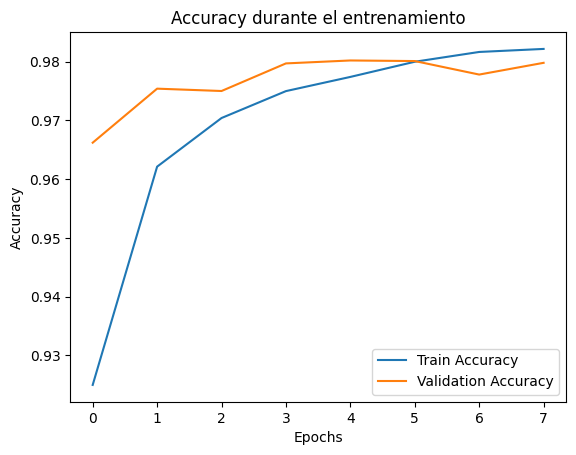

In [184]:
plt.figure()
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title('Accuracy durante el entrenamiento')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

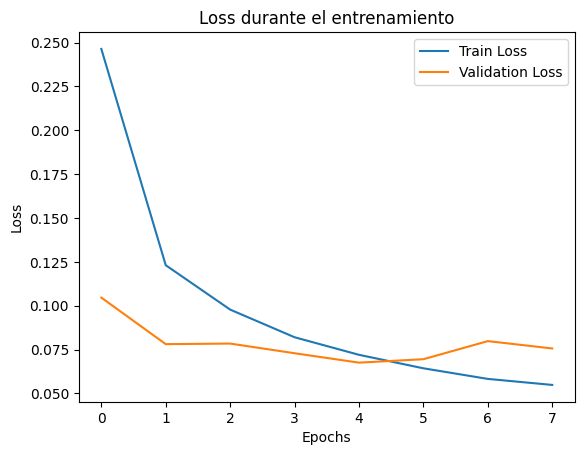

In [185]:
plt.figure()
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title('Loss durante el entrenamiento')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

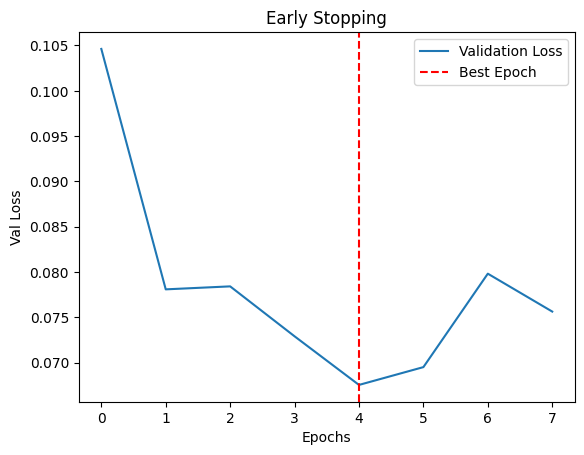

In [186]:
best_epoch = history.history['val_loss'].index(min(history.history['val_loss']))

plt.figure()
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.axvline(best_epoch, color='r', linestyle='--', label='Best Epoch')

plt.title('Early Stopping')
plt.xlabel('Epochs')
plt.ylabel('Val Loss')
plt.legend()
plt.show()

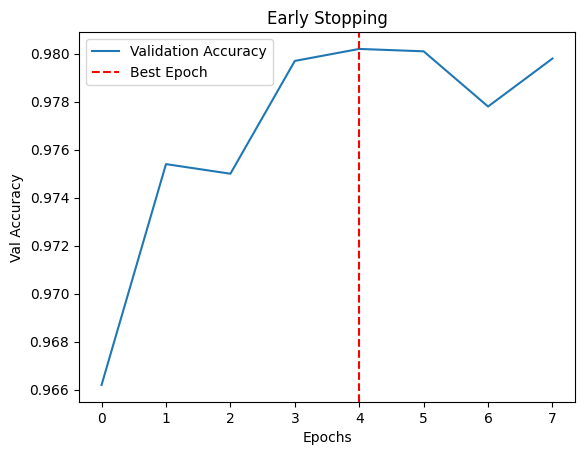

In [188]:
best_epoch = history.history['val_accuracy'].index(max(history.history['val_accuracy']))

plt.figure()
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.axvline(best_epoch, color='r', linestyle='--', label='Best Epoch')

plt.title('Early Stopping')
plt.xlabel('Epochs')
plt.ylabel('Val Accuracy')
plt.legend()
plt.show()

***Respuesta:***

A pesar que los modelos anteriores ya superaban un accuracy al 95%, se está aplicando técnicas para mejorar la capacidad de generalización y evitar sobreajustes.

Se ha utiliza las siguientes caracteristicas durante este último entrenamiento:

* Capas con Dropout: Permite desactivar el 30% de neuronas duramente el entrenamiento, mitigando que el modelo memorice los datos de entrenamiento.
* Early Stopping: Se detiene el entrenamiento cuando el modelo deja de mejorar durante en la metrica de validación de perdida durante 3 epocas. Esto permite acortar el tiempo de entrenamiento de 15 epocas configuradas inicialmente a 8, reduciendo el tiempo de procesamiento y entrenamiento a casi la mitad.
* Restore Best Weights: Se utiliza junto con Early Stopping para recuperar los pesos correspondientes a la mejor época antes de detener el entrenamiento, asurando así el mejor rendimiento del modelo.

Las gráficas demuestran la evolución de la accuracy y la función de perdida tanto en entrenamiento como en validación. El comportamiento en ambas metricas es estable y progresiva. Sin embargo a partir de ciestas épocas, la perdida y accuracy en validación dejan de mejorar. Si siguieramos entrenando podriamos incurrir en sobreajuste, por lo que el early stopping detiene el entrenamiento en el punto óptimo. El punto óptimo de las metricas de accuracy y perdida en validación se alcanza en la época 4 del entrenamiento.

